# PINNeAPPle Demo
## 3D Steady Heat (Laplace) — Reference Solver vs PINN

This notebook demonstrates an end-to-end **Physics-Informed Neural Network (PINN)** workflow using **PINNeAPPle** where available:
- Create a **fictitious geometry** (STL-like mesh)
- Generate **collocation & boundary points**
- Build a **reference solution** with a lightweight numerical baseline (finite-difference on the geometry bounding box)
- Define a **symbolic PDE** (SymPy) and train a **PINN** to satisfy the physics + boundary conditions
- Visualize **reference vs PINN** and **error slices**

> Notes:
> - The current PINNeAPPle repo may not yet expose a full volumetric FEM solver for arbitrary STL domains.
>   This demo uses a robust **FD baseline** on the mesh bounding box to keep the notebook self-contained and reproducible.
> - The geometry still comes from a mesh asset (and can be exported to STL).

## 0) Setup (Colab)
Run this cell once. It clones PINNeAPPle and installs dependencies.

In [1]:
# --- Colab setup ---
!git clone https://github.com/barrosyan/PINNeAPPle.git
%cd PINNeAPPle
!pip -q install -e .
!pip -q install trimesh sympy matplotlib tqdm

Cloning into 'PINNeAPPle'...
remote: Enumerating objects: 2214, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 2214 (delta 3), reused 1 (delta 1), pack-reused 2208 (from 1)
Receiving objects: 100% (2214/2214), 3.54 MiB | 8.10 MiB/s, done.
Resolving deltas: 100% (745/745), done.
/content/PINNeAPPle
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 88.2 MB/s eta 0:00:00
  Building editable for pinneaple (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.3/740.3 kB 16.4 MB/s eta 0:00:00


## 1) Imports & device

In [2]:
import os, math, random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import sympy as sp

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float32)
device

device(type='cuda')

## 2) Geometry (fictitious) via PINNeAPPle (with fallback)

We try to use `pinneaple_geom` to create a mesh asset. If the API differs in your current commit,
we fall back to creating a simple mesh with `trimesh`.

In [3]:
# --- Geometry creation ---
os.makedirs("artifacts", exist_ok=True)

mesh = None
asset = None
stl_path = "artifacts/toy_geometry.stl"

try:
    from pinneaple_geom import GeometrySpec, build_geometry_asset
    # Simple primitive box (normalized to unit box)
    spec = GeometrySpec(kind="primitive", name="box", params=dict(extents=(1.0, 0.6, 0.6)))
    asset = build_geometry_asset(
        spec,
        options=type("Opt", (), dict(
            normalize_to_unit_box=True,
            center_to_origin=True,
            auto_bbox_boundary_groups=True,
            bbox_boundary_tol=1e-6,
            ensure_normals=True
        ))()
    )
    mesh = asset.mesh
    print("✅ Using PINNeAPPle geometry pipeline.")
    try:
        # Export to STL for demonstration
        import trimesh
        tm = trimesh.Trimesh(vertices=mesh.vertices, faces=mesh.faces, process=False)
        tm.export(stl_path)
        print("STL exported:", stl_path)
    except Exception as e:
        print("STL export skipped:", e)

except Exception as e:
    print("⚠️ PINNeAPPle geometry API not available in this commit. Falling back to trimesh.")
    import trimesh
    box = trimesh.creation.box(extents=(1.0, 0.6, 0.6))
    box.export(stl_path)
    print("STL exported:", stl_path)
    # Create minimal mesh-like wrapper
    class _MeshWrap:
        def __init__(self, tm):
            self.vertices = np.asarray(tm.vertices, dtype=np.float32)
            self.faces = np.asarray(tm.faces, dtype=np.int64)
        def bounds(self):
            b = np.asarray(tm.bounds, dtype=np.float32)
            return b[0], b[1]
    mesh = _MeshWrap(box)

# Bounds
b0, b1 = mesh.bounds()
b0 = np.asarray(b0, dtype=np.float32)
b1 = np.asarray(b1, dtype=np.float32)
b0, b1

✅ Using PINNeAPPle geometry pipeline.
STL exported: artifacts/toy_geometry.stl


(array([-0.5, -0.3, -0.3], dtype=float32),
 array([0.5, 0.3, 0.3], dtype=float32))

## 3) Reference solver (FD on the bounding box)

We solve the **steady heat equation** (Laplace):

\[
\nabla^2 T = 0
\]

Dirichlet BCs:
- **T=1** on *xmin*
- **T=0** on *xmax*
- **T=0** on remaining bounding faces (simplifies the demo; can be changed to Neumann later)

This yields a stable baseline for quantitative comparison.

In [4]:
# --- Reference solver grid ---
nx, ny, nz = 18, 14, 14  # moderate size for Colab
xs = np.linspace(b0[0], b1[0], nx).astype(np.float32)
ys = np.linspace(b0[1], b1[1], ny).astype(np.float32)
zs = np.linspace(b0[2], b1[2], nz).astype(np.float32)

dx = float(xs[1]-xs[0]); dy = float(ys[1]-ys[0]); dz = float(zs[1]-zs[0])

def lin(i,j,k):
    return (k*ny + j)*nx + i

N = nx*ny*nz

# Dirichlet boundary indices and values
I_dir = []
T_dir = []
for k in range(nz):
    for j in range(ny):
        for i in range(nx):
            on = (i==0) or (i==nx-1) or (j==0) or (j==ny-1) or (k==0) or (k==nz-1)
            if on:
                I_dir.append(lin(i,j,k))
                if i == 0:         # xmin
                    T_dir.append(1.0)
                elif i == nx-1:    # xmax
                    T_dir.append(0.0)
                else:
                    T_dir.append(0.0)

I_dir = np.asarray(I_dir, dtype=np.int64)
T_dir = np.asarray(T_dir, dtype=np.float32)

# Build K, f (dense for clarity). For larger grids, switch to sparse.
K = np.zeros((N, N), dtype=np.float32)
f = np.zeros((N,), dtype=np.float32)

cx = 1.0/(dx*dx); cy = 1.0/(dy*dy); cz = 1.0/(dz*dz)

for k in range(nz):
    for j in range(ny):
        for i in range(nx):
            p = lin(i,j,k)
            if (0<i<nx-1) and (0<j<ny-1) and (0<k<nz-1):
                K[p,p] = -2*cx - 2*cy - 2*cz
                K[p, lin(i-1,j,k)] = cx
                K[p, lin(i+1,j,k)] = cx
                K[p, lin(i,j-1,k)] = cy
                K[p, lin(i,j+1,k)] = cy
                K[p, lin(i,j,k-1)] = cz
                K[p, lin(i,j,k+1)] = cz
            else:
                # boundary row overwritten by Dirichlet
                K[p,p] = 1.0
                f[p] = 0.0

# Apply Dirichlet: K[row,:]=0, K[row,row]=1, f[row]=T_dir
K[I_dir, :] = 0.0
K[I_dir, I_dir] = 1.0
f[I_dir] = T_dir

# Solve
T_ref = np.linalg.solve(K, f).astype(np.float32)  # (N,)
print("T_ref min/max:", float(T_ref.min()), float(T_ref.max()))

# reshape to (nx, ny, nz)
T_ref_vol = T_ref.reshape(nz, ny, nx).transpose(2,1,0)

T_ref min/max: -5.026593833008797e-13 1.0


## 4) Symbolic PDE (SymPy)

We define the Laplacian symbolically:

\[
\nabla^2 T = T_{xx} + T_{yy} + T_{zz}
\]

The PINN uses PyTorch autograd for derivatives, but SymPy makes the PDE explicit and auditable.

In [5]:
x, y, z = sp.symbols("x y z", real=True)
T = sp.Function("T")(x, y, z)
laplace = sp.diff(T, x, 2) + sp.diff(T, y, 2) + sp.diff(T, z, 2)
laplace

Derivative(T(x, y, z), (x, 2)) + Derivative(T(x, y, z), (y, 2)) + Derivative(T(x, y, z), (z, 2))

## 5) PINN model via PINNeAPPle (with fallback)

We try to use `pinneaple_models.pinns.vanilla.VanillaPINN`.
If unavailable, we fall back to an equivalent MLP.

In [6]:
# --- PINN model ---
VanillaPINN = None
try:
    from pinneaple_models.pinns.vanilla import VanillaPINN
    print("✅ Using PINNeAPPle VanillaPINN.")
except Exception as e:
    print("⚠️ VanillaPINN not available; using fallback MLP. Error:", e)

class FallbackMLP(nn.Module):
    def __init__(self, in_dim=3, width=128, depth=5, out_dim=1):
        super().__init__()
        layers = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(depth-1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, out_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

if VanillaPINN is not None:
    model = VanillaPINN(in_dim=3, out_dim=1, hidden=[128,128,128,128], activation="tanh").to(device)
    def model_forward(X):
        return model.net(X)
else:
    model = FallbackMLP(in_dim=3, width=128, depth=5, out_dim=1).to(device)
    def model_forward(X):
        return model(X)

model

✅ Using PINNeAPPle VanillaPINN.


VanillaPINN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
  (inverse_params): ParameterDict()
)

## 6) Collocation & Boundary points (PINNeAPPle if available)

- Interior points sampled within the mesh bounding box
- Boundary points sampled on the 6 bbox planes and labeled by group id (xmin/xmax/…)

We normalize inputs to **[-1, 1]** for more stable second derivatives.

In [7]:
def normalize_to_minus1_1(X, b0, b1):
    # map [b0,b1] -> [-1,1]
    return 2.0*(X - b0)/(b1 - b0 + 1e-12) - 1.0

# Sample points
n_int = 20000
n_bnd = 5000

pack = None
try:
    pack = mesh.sample_collocation(
        n_interior=n_int,
        n_boundary=n_bnd,
        interior_domain="bbox",
        boundary_mode="bbox_planes",
        boundary_groups=mesh.boundary_groups_bbox(tol=1e-6)
    )
    X_int = pack["X_int"].astype(np.float32)
    X_bnd = pack["X_bnd"].astype(np.float32)
    bnd_gid = pack.get("bnd_group_id", np.full((len(X_bnd),), -1, dtype=np.int64)).astype(np.int64)
    print("✅ Using PINNeAPPle collocation sampling.")
except Exception as e:
    print("⚠️ PINNeAPPle sampling not available; using numpy sampling. Error:", e)
    X_int = np.random.uniform(low=b0, high=b1, size=(n_int,3)).astype(np.float32)
    X_bnd = np.random.uniform(low=b0, high=b1, size=(n_bnd,3)).astype(np.float32)
    bnd_gid = np.random.randint(0, 6, size=(n_bnd,), dtype=np.int64)
    for i in range(n_bnd):
        g = bnd_gid[i]
        if g == 0: X_bnd[i,0] = b0[0]
        if g == 1: X_bnd[i,0] = b1[0]
        if g == 2: X_bnd[i,1] = b0[1]
        if g == 3: X_bnd[i,1] = b1[1]
        if g == 4: X_bnd[i,2] = b0[2]
        if g == 5: X_bnd[i,2] = b1[2]

# Boundary labels: xmin=1, xmax=0, others=0
T_bnd = np.zeros((len(X_bnd),), dtype=np.float32)
T_bnd[bnd_gid == 0] = 1.0   # xmin
T_bnd[bnd_gid == 1] = 0.0   # xmax

# Normalize
X_int_n = normalize_to_minus1_1(X_int, b0, b1)
X_bnd_n = normalize_to_minus1_1(X_bnd, b0, b1)

X_int_t = torch.tensor(X_int_n, device=device, dtype=torch.float32, requires_grad=True)
X_bnd_t = torch.tensor(X_bnd_n, device=device, dtype=torch.float32)
T_bnd_t = torch.tensor(T_bnd, device=device, dtype=torch.float32).unsqueeze(1)

X_int_t.shape, X_bnd_t.shape, T_bnd_t.shape

✅ Using PINNeAPPle collocation sampling.


(torch.Size([20000, 3]), torch.Size([5000, 3]), torch.Size([5000, 1]))

## 7) Physics loss: Laplacian residual + boundary loss

We compute:

- PDE: \( \mathcal{L}_{pde} = \| \nabla^2 T \|^2 \)
- BC:  \( \mathcal{L}_{bc} = \| T - T_{bc} \|^2 \)

We use a simple **adaptive weighting** so the BC doesn't dominate forever:
\[
\lambda_{bc} = \frac{\mathcal{L}_{pde}}{\mathcal{L}_{bc} + \epsilon}
\]

In [8]:
def laplace_residual(u, X):
    grads = torch.autograd.grad(u, X, grad_outputs=torch.ones_like(u), create_graph=True)[0]  # (N,3)
    u_x = grads[:,0:1]; u_y = grads[:,1:2]; u_z = grads[:,2:3]
    u_xx = torch.autograd.grad(u_x, X, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:,0:1]
    u_yy = torch.autograd.grad(u_y, X, grad_outputs=torch.ones_like(u_y), create_graph=True)[0][:,1:2]
    u_zz = torch.autograd.grad(u_z, X, grad_outputs=torch.ones_like(u_z), create_graph=True)[0][:,2:3]
    return u_xx + u_yy + u_zz

def compute_losses():
    u_int = model_forward(X_int_t)
    r = laplace_residual(u_int, X_int_t)
    loss_pde = (r**2).mean()

    u_bnd = model_forward(X_bnd_t)
    loss_bc = ((u_bnd - T_bnd_t)**2).mean()

    lam_bc = (loss_pde.detach() / (loss_bc.detach() + 1e-12)).clamp(1.0, 200.0)
    loss = loss_pde + lam_bc * loss_bc
    return loss, loss_pde.detach(), loss_bc.detach(), lam_bc.detach()

## 8) Train the PINN

In [9]:
opt = torch.optim.Adam(model.parameters(), lr=2e-3)
history = {"step": [], "loss": [], "pde": [], "bc": [], "lam_bc": []}

steps = 2500
for step in tqdm(range(steps)):
    opt.zero_grad()
    loss, lpde, lbc, lam = compute_losses()
    loss.backward()
    opt.step()

    if step % 50 == 0:
        history["step"].append(step)
        history["loss"].append(float(loss.detach().cpu()))
        history["pde"].append(float(lpde.cpu()))
        history["bc"].append(float(lbc.cpu()))
        history["lam_bc"].append(float(lam.cpu()))

print("Done. Final loss:", history["loss"][-1])

  0%|          | 0/2500 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Done. Final loss: 0.01471713650971651


## 9) Evaluate on the reference grid and visualize

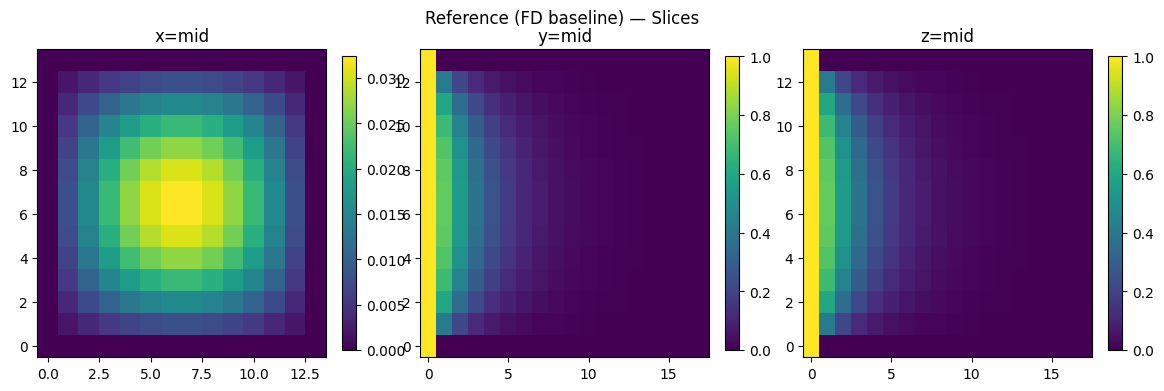

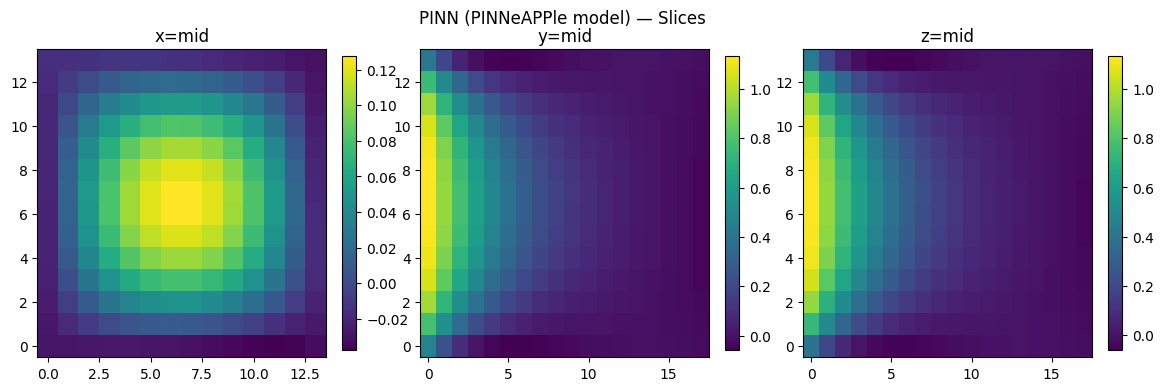

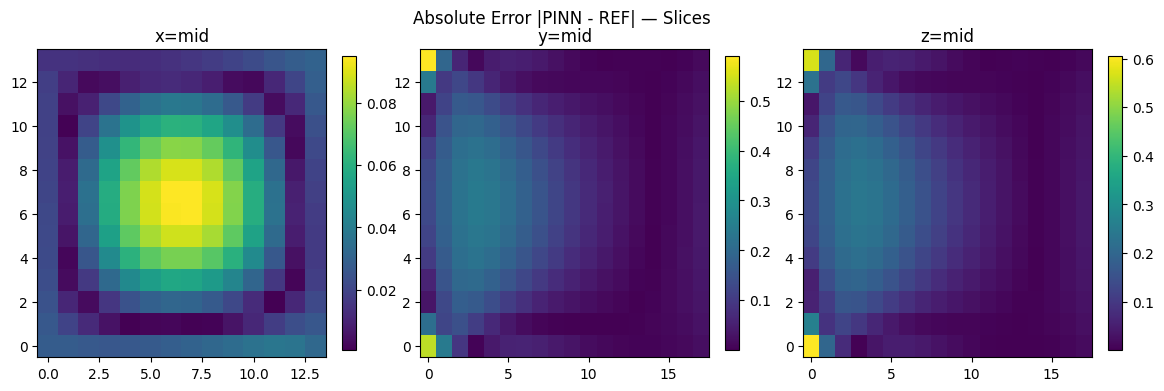

MAE: 0.06619194149971008 RMSE: 0.11406400799751282


In [10]:
def show_slices(vol, title):
    ix, iy, iz = vol.shape[0]//2, vol.shape[1]//2, vol.shape[2]//2
    fig, ax = plt.subplots(1,3, figsize=(14,4))
    fig.suptitle(title)

    im0 = ax[0].imshow(vol[ix,:,:].T, origin="lower", aspect="auto")
    ax[0].set_title("x=mid"); plt.colorbar(im0, ax=ax[0], fraction=0.046)

    im1 = ax[1].imshow(vol[:,iy,:].T, origin="lower", aspect="auto")
    ax[1].set_title("y=mid"); plt.colorbar(im1, ax=ax[1], fraction=0.046)

    im2 = ax[2].imshow(vol[:,:,iz].T, origin="lower", aspect="auto")
    ax[2].set_title("z=mid"); plt.colorbar(im2, ax=ax[2], fraction=0.046)
    plt.show()

# Evaluate PINN on the reference grid nodes
Xg = np.stack(np.meshgrid(xs, ys, zs, indexing="ij"), axis=-1).astype(np.float32)  # (nx,ny,nz,3)
Xg_n = normalize_to_minus1_1(Xg.reshape(-1,3), b0, b1).astype(np.float32)
Xg_t = torch.tensor(Xg_n, device=device, dtype=torch.float32)

with torch.no_grad():
    T_pinn = model_forward(Xg_t).squeeze(1).detach().cpu().numpy().astype(np.float32)

T_pinn_vol = T_pinn.reshape(nx, ny, nz)
err_vol = np.abs(T_pinn_vol - T_ref_vol)

show_slices(T_ref_vol, "Reference (FD baseline) — Slices")
show_slices(T_pinn_vol, "PINN (PINNeAPPle model) — Slices")
show_slices(err_vol, "Absolute Error |PINN - REF| — Slices")

mae = float(np.mean(err_vol))
rmse = float(np.sqrt(np.mean(err_vol**2)))
print("MAE:", mae, "RMSE:", rmse)

## 10) Training diagnostics

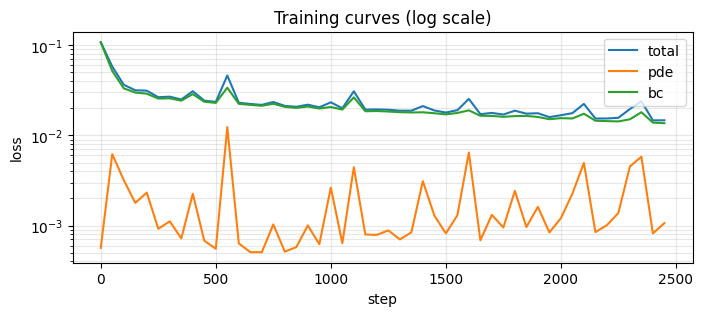

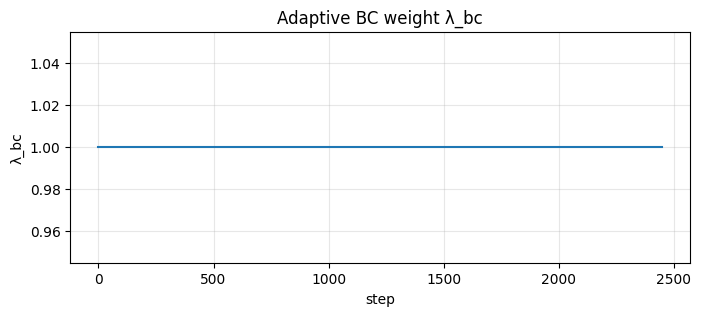

In [11]:
plt.figure(figsize=(8,3))
plt.plot(history["step"], history["loss"], label="total")
plt.plot(history["step"], history["pde"], label="pde")
plt.plot(history["step"], history["bc"], label="bc")
plt.yscale("log")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.title("Training curves (log scale)")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

plt.figure(figsize=(8,3))
plt.plot(history["step"], history["lam_bc"])
plt.grid(True, alpha=0.3)
plt.title("Adaptive BC weight λ_bc")
plt.xlabel("step")
plt.ylabel("λ_bc")
plt.show()